## Aprendizaje no supervisado

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [38]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [40]:
print(data.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [42]:
data = data.drop(columns=["CustomerID", "Gender"])

In [44]:
print(data.info())
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


In [46]:
print(data.isna().sum())

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


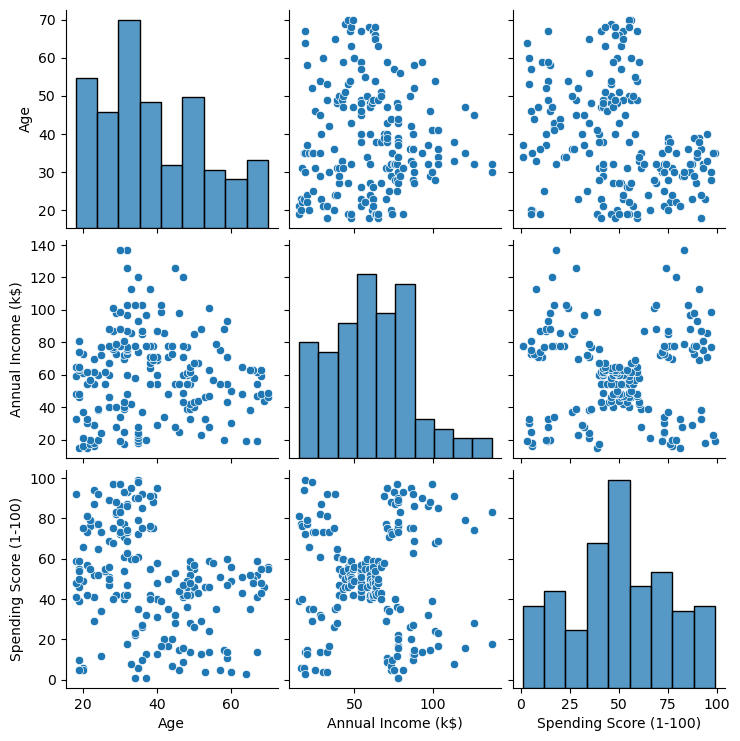

In [48]:
sns.pairplot(data)
plt.show()

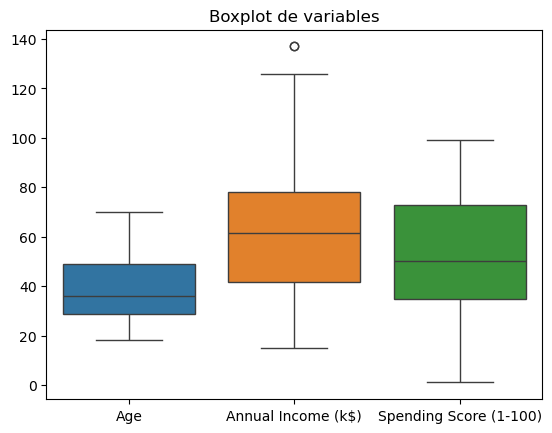

In [49]:
sns.boxplot(data=data)
plt.title("Boxplot de variables")
plt.show()

In [50]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

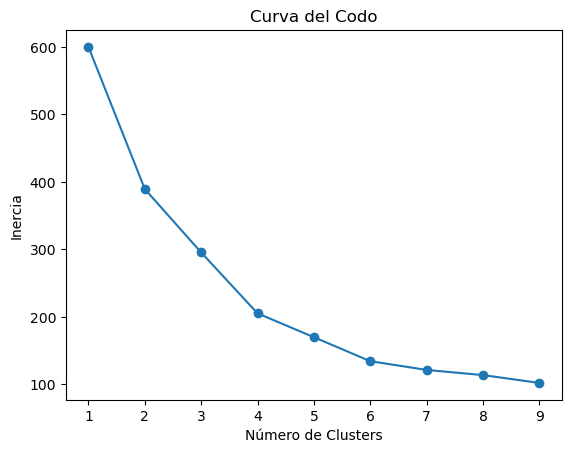

In [51]:
Nc = range(1, 10)
kmeans_models = [KMeans(n_clusters=i, random_state=42).fit(X) for i in Nc]
scores = [model.inertia_ for model in kmeans_models]

plt.plot(Nc, scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Curva del Codo')
plt.show()

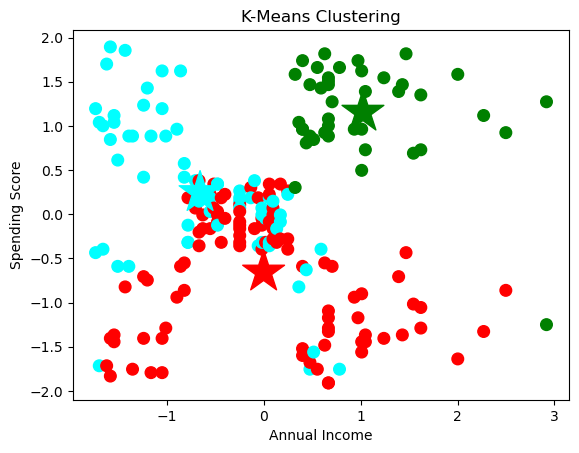

In [52]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

colores = ['red', 'green', 'cyan']
asignar = [colores[i] for i in labels_kmeans]

f1 = X['Annual Income (k$)'].values
f2 = X['Spending Score (1-100)'].values
plt.scatter(f1, f2, c=asignar, s=70)
plt.scatter(centroids[:, 1], centroids[:, 2], marker='*', c=colores, s=1000)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [53]:
print("Medidas de calidad para K-Means:")
print("Puntaje de silueta:", silhouette_score(X, labels_kmeans))
print("Índice de Calinski-Harabasz:", calinski_harabasz_score(X, labels_kmeans))
print("Davies-Bouldin Index:", davies_bouldin_score(X, labels_kmeans))

Medidas de calidad para K-Means:
Puntaje de silueta: 0.3579234303882264
Índice de Calinski-Harabasz: 101.52961865209923
Davies-Bouldin Index: 1.032688958457893


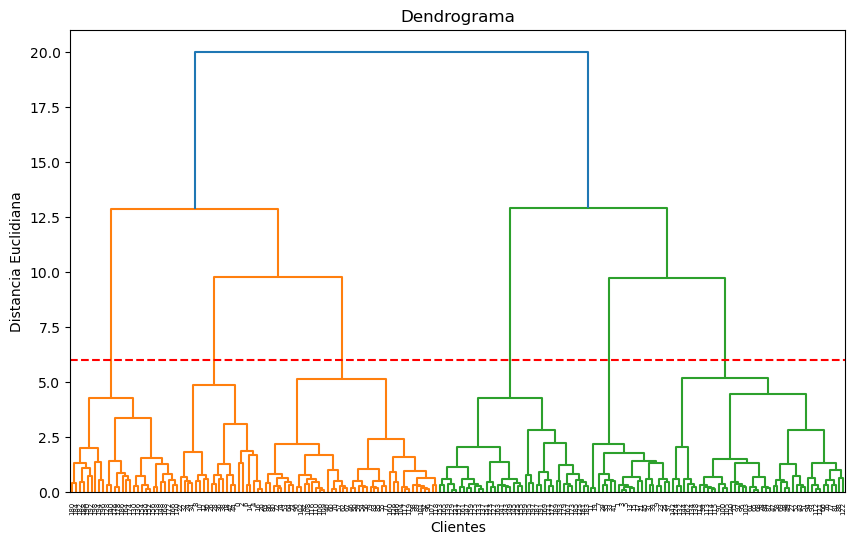

In [26]:
linkage_matrix = linkage(X, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.axhline(y=6, color='r', linestyle='--')
plt.title("Dendrograma")
plt.xlabel("Clientes")
plt.ylabel("Distancia Euclidiana")
plt.show()

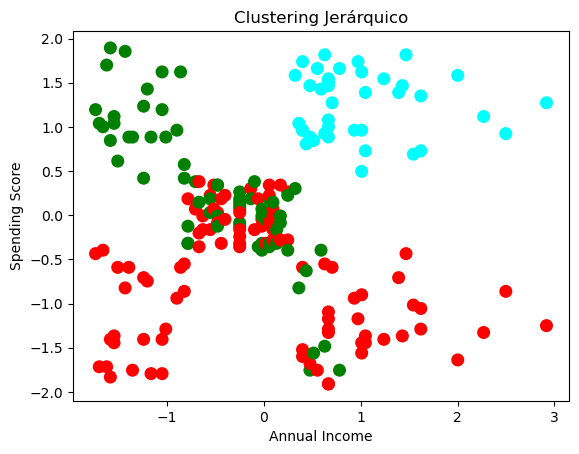

In [28]:
hier = AgglomerativeClustering(n_clusters=3)
labels_hier = hier.fit_predict(X)

asignar = [colores[i] for i in labels_hier]
plt.scatter(f1, f2, c=asignar, s=70)
plt.title('Clustering Jerárquico')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [30]:
print("Medidas de calidad para Clustering Jerárquico:")
print("Puntaje de silueta:", silhouette_score(X, labels_hier))
print("Índice de Calinski-Harabasz:", calinski_harabasz_score(X, labels_hier))
print("Davies-Bouldin Index:", davies_bouldin_score(X, labels_hier))

Medidas de calidad para Clustering Jerárquico:
Puntaje de silueta: 0.32148866683112387
Índice de Calinski-Harabasz: 88.10174149244529
Davies-Bouldin Index: 1.1277290061047862


In [32]:
X_dist = pdist(X)
Z = linkage(X, 'ward')
coef, _ = cophenet(Z, X_dist)
print("Coeficiente de correlación cofenética:", coef)

Coeficiente de correlación cofenética: 0.6261774947075186


## Conclusiones 

El análisis de clustering sobre el dataset Mall_Customers.csv permitió identificar tres segmentos bien definidos 
de clientes utilizando tanto K-Means como Clustering Jerárquico. Tras la limpieza y estandarización de los datos, 
el método del codo y el dendrograma indicaron que tres es el número óptimo de clusters. Ambos métodos agruparon a los 
clientes de manera coherente, revelando perfiles diferenciados según su ingreso anual y puntuación de gasto. Las métricas de 
calidad como la silueta, Calinski-Harabasz y Davies-Bouldin. Confirmaron una buena separación entre los grupos, y el coeficiente 
de correlación cofenética indicó que la jerarquía del dendrograma representaba fielmente las distancias reales.